In [ ]:
#pip install pandas

  Using cached pandas-2.3.3-cp310-cp310-win_amd64.whl (11.3 MB)
  Using cached pytz-2026.2-py2.py3-none-any.whl (510 kB)
  Using cached numpy-2.2.6-cp310-cp310-win_amd64.whl (12.9 MB)
  Using cached tzdata-2026.2-py2.py3-none-any.whl (349 kB)
Note: you may need to restart the kernel to use updated packages.


  Consider adding this directory to PATH or, if you prefer to suppress this warning, use --no-warn-script-location.

[notice] A new release of pip available: 22.3.1 -> 26.1.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [ ]:
#pip install numpy


[notice] A new release of pip available: 22.3.1 -> 26.1.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [ ]:
#pip install matplotlib

  Using cached matplotlib-3.10.9-cp310-cp310-win_amd64.whl (8.2 MB)
  Using cached contourpy-1.3.2-cp310-cp310-win_amd64.whl (221 kB)
  Using cached fonttools-4.63.0-cp310-cp310-win_amd64.whl (1.6 MB)
  Using cached pyparsing-3.3.2-py3-none-any.whl (122 kB)
  Using cached pillow-12.2.0-cp310-cp310-win_amd64.whl (7.1 MB)
  Using cached kiwisolver-1.5.0-cp310-cp310-win_amd64.whl (73 kB)
  Using cached cycler-0.12.1-py3-none-any.whl (8.3 kB)
Note: you may need to restart the kernel to use updated packages.


  Consider adding this directory to PATH or, if you prefer to suppress this warning, use --no-warn-script-location.

[notice] A new release of pip available: 22.3.1 -> 26.1.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [ ]:
#pip install seaborn

     ------------------------------------ 294.9/294.9 kB 293.8 kB/s eta 0:00:00
Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip available: 22.3.1 -> 26.1.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [ ]:
#pip install scikit-learn

  Using cached scikit_learn-1.7.2-cp310-cp310-win_amd64.whl (8.9 MB)
  Using cached scipy-1.15.3-cp310-cp310-win_amd64.whl (41.3 MB)
  Using cached joblib-1.5.3-py3-none-any.whl (309 kB)
  Using cached threadpoolctl-3.6.0-py3-none-any.whl (18 kB)
Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip available: 22.3.1 -> 26.1.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [ ]:
#pip install nltk

  Using cached nltk-3.9.4-py3-none-any.whl (1.6 MB)
  Using cached click-8.4.0-py3-none-any.whl (116 kB)
  Using cached tqdm-4.67.3-py3-none-any.whl (78 kB)
  Using cached regex-2026.5.9-cp310-cp310-win_amd64.whl (278 kB)
Note: you may need to restart the kernel to use updated packages.


  Consider adding this directory to PATH or, if you prefer to suppress this warning, use --no-warn-script-location.
  Consider adding this directory to PATH or, if you prefer to suppress this warning, use --no-warn-script-location.

[notice] A new release of pip available: 22.3.1 -> 26.1.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [ ]:
#pip install wordcloud

  Using cached wordcloud-1.9.6-cp310-cp310-win_amd64.whl (306 kB)
Note: you may need to restart the kernel to use updated packages.


  Consider adding this directory to PATH or, if you prefer to suppress this warning, use --no-warn-script-location.

[notice] A new release of pip available: 22.3.1 -> 26.1.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [23]:
# STEP 1 — Import Libraries

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import re
import nltk

from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer

In [24]:
# STEP 2 — Download NLTK Resources

import nltk
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer


nltk.download('stopwords')
nltk.download('wordnet')

[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\ASUS\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package wordnet to
[nltk_data]     C:\Users\ASUS\AppData\Roaming\nltk_data...
[nltk_data]   Package wordnet is already up-to-date!


True

In [25]:
#Load Dataset
df = pd.read_csv("sentiment analysis.csv")

In [26]:
# STEP 4 — View Dataset

print(df.head())

   Complaint ID                       Category              Sub Category  \
0      20771690                     Electrical  Street Light Not Working   
1      20771689                     Electrical  Street Light Not Working   
2      20771688  Solid Waste (Garbage) Related              Garbage dump   
3      20771687                     Electrical  Street Light Not Working   
4      20771686  Solid Waste (Garbage) Related              Garbage dump   

                  Grievance Date            Ward Name Grievance Status  \
0  2025-06-19 10:39:00.000000000  Jagajeevanram Nagar       Registered   
1  2025-06-19 10:36:00.000000000         Kammanahalli       Registered   
2  2025-06-19 10:35:00.000000000            Banaswadi       Registered   
3  2025-06-19 10:34:00.000000000         Gandhi Nagar       Registered   
4  2025-06-19 10:34:00.000000000   Kumaraswamy Layout       Registered   

                          Staff Remarks                   Staff Name  
0  1st Assignment Based on 

In [27]:
# STEP 5 — Select Required Columns

df = df[['Sub Category', 'Category']]

df.columns = ['Complaint', 'Department']

print(df.head())

                  Complaint                     Department
0  Street Light Not Working                     Electrical
1  Street Light Not Working                     Electrical
2              Garbage dump  Solid Waste (Garbage) Related
3  Street Light Not Working                     Electrical
4              Garbage dump  Solid Waste (Garbage) Related


In [28]:
# STEP 6 — Dataset Info

print(df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 126974 entries, 0 to 126973
Data columns (total 2 columns):
 #   Column      Non-Null Count   Dtype 
---  ------      --------------   ----- 
 0   Complaint   126974 non-null  object
 1   Department  126974 non-null  object
dtypes: object(2)
memory usage: 1.9+ MB
None


In [29]:
# STEP 7 — Check Missing Values

print(df.isnull().sum())

Complaint     0
Department    0
dtype: int64


In [30]:
# STEP 8 — Remove Missing Values

df.dropna(inplace=True)

In [31]:
# STEP 9 — Check Duplicate Values

print("Duplicate Rows :", df.duplicated().sum())

Duplicate Rows : 126789


In [32]:
# STEP 10 — Remove Duplicate Values

df.drop_duplicates(inplace=True)

In [33]:
# STEP 11 — Create Stopwords and Lemmatizer

stop_words = set(stopwords.words('english'))

lemmatizer = WordNetLemmatizer()

In [34]:
# STEP 12 — Text Cleaning Function

def clean_text(text):

    text = text.lower()

    text = re.sub(r'[^a-zA-Z ]', '', text)

    tokens = text.split()

    tokens = [word for word in tokens if word not in stop_words]

    tokens = [lemmatizer.lemmatize(word) for word in tokens]

    return " ".join(tokens)

In [35]:
# STEP 13 — Apply Text Cleaning

df['Cleaned_Complaint'] = df['Complaint'].apply(clean_text)

print(df.head())

                                        Complaint  \
0                        Street Light Not Working   
2                                    Garbage dump   
9                           footpath encroachment   
11                   Stray dog related complaints   
12  Animal Rescue - Not well - Requires attention   

                       Department                      Cleaned_Complaint  
0                      Electrical                   street light working  
2   Solid Waste (Garbage) Related                           garbage dump  
9          Road Maintenance(Engg)                  footpath encroachment  
11                     veterinary            stray dog related complaint  
12                     veterinary  animal rescue well requires attention  


In [36]:
# STEP 14 — Dataset Shape

print("Dataset Shape :", df.shape)

Dataset Shape : (185, 3)


In [37]:
# STEP 15 — Department Distribution

print(df['Department'].value_counts())

Department
veterinary                       35
Health Dept                      14
E khata / Khata services         13
Road Maintenance(Engg)           11
Solid Waste (Garbage) Related    11
Lakes                            11
Indira Canteen                    9
Markets                           6
Welfare Schemes                   6
Electrical                        6
Property Tax services             6
Revenue Department                5
Sanitation                        5
Projects Central                  5
Parks and Play grounds            5
CORONA COVID19                    5
Estate                            4
Town Planning                     4
Education                         4
Forest                            3
Storm  Water Drain(SWD)           3
Information Technology            2
Advertisement                     2
BBMP Election Branch              2
Call Center                       2
Others                            1
Road Infrastructure               1
Plastic          

VISUALIZATION

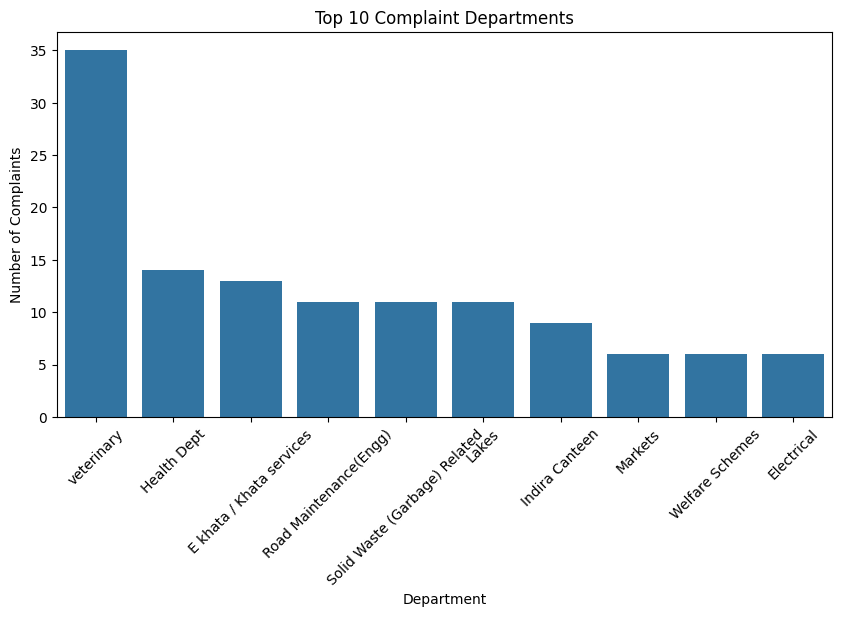

In [38]:
# Visualization 1 — Top 10 Departments

plt.figure(figsize=(10,5))

top_departments = df['Department'].value_counts().head(10)

sns.barplot(
    x=top_departments.index,
    y=top_departments.values
)

plt.xticks(rotation=45)

plt.title("Top 10 Complaint Departments")

plt.xlabel("Department")

plt.ylabel("Number of Complaints")

plt.show()

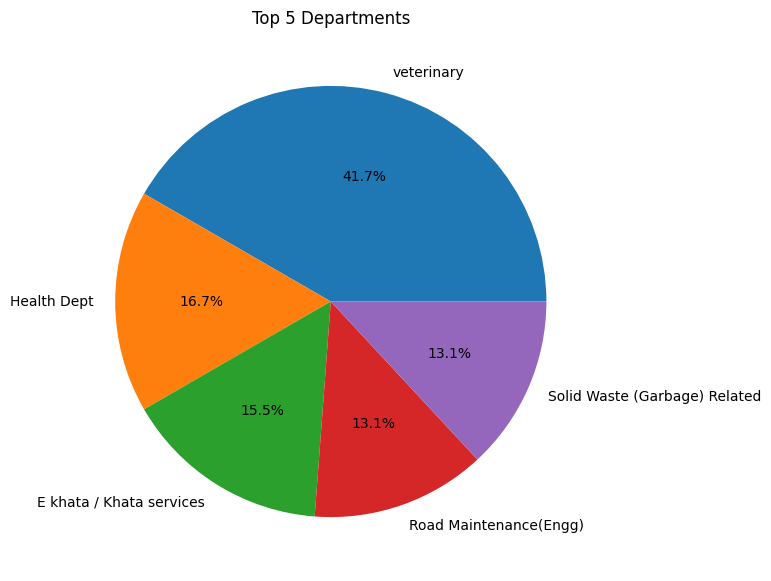

In [39]:
# Visualization 3 — Pie Chart of Departments

department_counts = df['Department'].value_counts().head(5)

plt.figure(figsize=(7,7))

plt.pie(
    department_counts.values,
    labels=department_counts.index,
    autopct='%1.1f%%'
)

plt.title("Top 5 Departments")

plt.show()

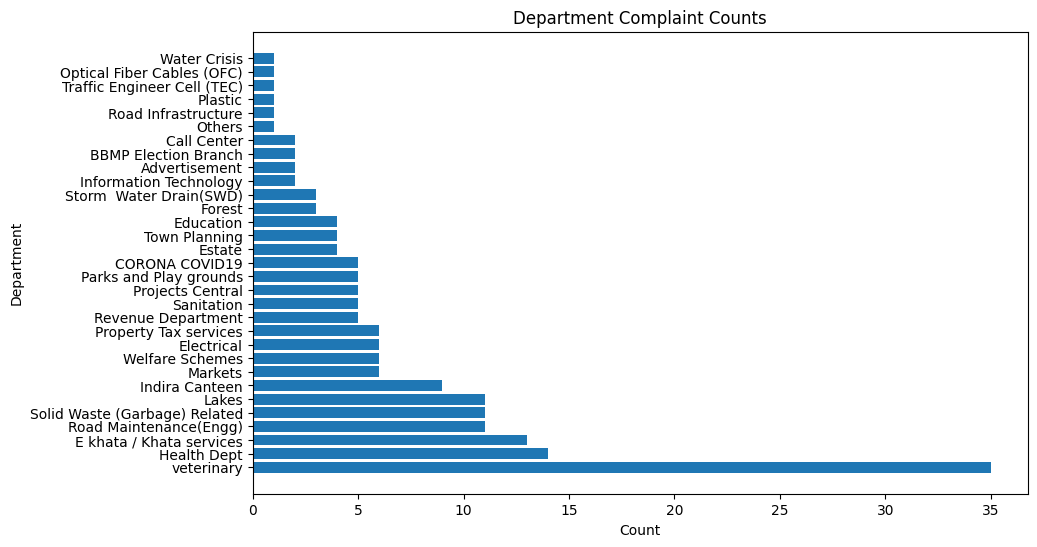

In [40]:
# Visualization — Horizontal Bar Chart

dept_counts = df['Department'].value_counts()

plt.figure(figsize=(10,6))

plt.barh(
    dept_counts.index,
    dept_counts.values
)

plt.title("Department Complaint Counts")

plt.xlabel("Count")

plt.ylabel("Department")

plt.show()

In [41]:
# STEP 19 — Most Common Words

from collections import Counter

all_words = " ".join(df['Cleaned_Complaint']).split()

common_words = Counter(all_words).most_common(10)

print(common_words)

[('issue', 20), ('dog', 14), ('related', 13), ('animal', 13), ('ekhata', 13), ('water', 10), ('property', 10), ('lake', 10), ('street', 9), ('garbage', 9)]
